[11501.226, 11365.373, 11657.229, 11253.548, 11731.797, 11425.535, 11490.822, 11427.991, 11391.313, 11483.611, 11544.635, 11495.342, 11410.776, 11376.869, 11362.153, 11260.109, 11300.564, 11361.338, 11374.753, 11329.086, 11614.831, 11367.712, 11192.993, 11466.207, 11496.749, 11287.966, 11362.309, 11312.091, 11431.083, 11381.872, 11368.807, 11499.817, 11298.871, 11412.241, 11302.056, 11493.964, 11220.753, 11377.16, 11390.166, 11554.022]


(array([ 2.,  5.,  3., 12.,  5.,  8.,  2.,  1.,  1.,  1.]),
 array([11192.993 , 11246.8734, 11300.7538, 11354.6342, 11408.5146,
        11462.395 , 11516.2754, 11570.1558, 11624.0362, 11677.9166,
        11731.797 ]),
 <BarContainer object of 10 artists>)

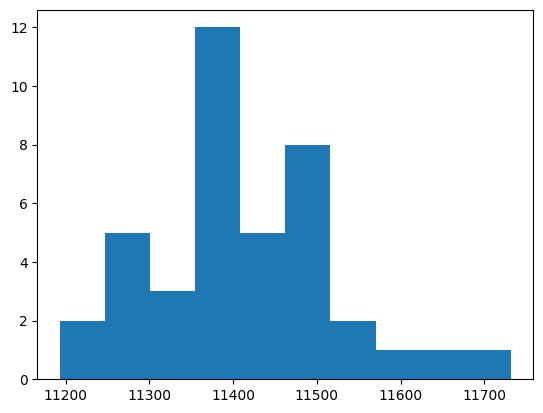

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math


prefix = "../results/"
instance = "pg_duckdb"
postfix = "_01_big_query.dat"
f = prefix + instance + postfix

t = []
with open(f, 'r') as file:
    for line in file:
        clear = line.strip()
        if clear:
            clear_dot = clear.replace(',', '.')
            t.append(float(clear_dot))
print(t)
plt.hist(t)

In [2]:
test_normal = stats.normaltest(t)
test_shapiro = stats.shapiro(t)
# print(test_normal, test_shapiro, sep = '\n')
print("Тест на нормальность данных: ", end='')
if test_normal[1] > 0.05 or test_shapiro[1] > 0.05:
    print("ПРОЙДЕН")
else:
    print("НЕ ПРОЙДЕН")

Тест на нормальность данных: ПРОЙДЕН


In [3]:
mean = np.mean(t)
std = np.std(t, ddof=1)
quality = (std / mean) * 100
print(f"Среднее: {mean}\nСтандартное отклонение: {std}\nОтношение std/mean (%): {quality}")

Среднее: 11409.3935
Стандартное отклонение: 114.8101565066302
Отношение std/mean (%): 1.0062774722129637


In [4]:
interval = stats.t.ppf(0.975, df=len(t)-1)*stats.sem(t)
print(f"Доверительный интервал: {interval}")

Доверительный интервал: 36.718069386986585


### Округление
- Погрешность: 40 (мс)
- Среднее: 11410 (мс)
### Итог
- Результирующее значение: 11410 ± 40 (мс)